# Estimación de compensaciones en el sector tecnológico

**Cuaderno reproducible de la tesis**

Universidad ESAN · Facultad de Ingeniería · Carrera de Ingeniería de Sistemas

Arian Antonio Garay Concha · Carlos Sebastián Ramos Flores

---

Este cuaderno reproduce el experimento completo del Capítulo IV. Llama a los mismos
módulos que los scripts del proyecto, de modo que no existe una implementación
alternativa que pueda divergir de la documentada.

**Requisitos previos:** entorno con las dependencias de `requirements.txt`. Los datos
se descargan automáticamente del repositorio oficial de Stack Overflow (licencia
ODbL 1.0) la primera vez que se ejecuta.

**Duración aproximada:** 8 minutos.

**Semilla:** 42, fijada en partición, inicialización de modelos y remuestreo.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEMILLA = 42
np.random.seed(SEMILLA)
print("Raíz del proyecto:", RAIZ)

Raíz del proyecto: /home/debugsito/Documents/local/tesis/tech-salary-prediction


## 1. Carga y preparación de los datos

El módulo de carga aplica los criterios de inclusión documentados en §3.2.4 y
devuelve, junto al conjunto resultante, el registro del efecto de cada filtro sobre
el tamaño muestral. Ese registro es el que alimenta la tabla del Capítulo IV: no se
transcribe a mano.

In [2]:
from src.data_loader_stackoverflow import cargar_encuesta, TARGET

df, registro = cargar_encuesta(anio="2023")
registro

,paso,criterio,n,descartados
0,0,Respuestas totales de la edición,89184,0
1,1,Reporta compensación anual,48019,41165
2,2,Situación de empleo: asalariado,43776,4243
3,3,Desarrollador profesional,40410,3366
4,4,País con al menos 30 observaciones,39682,728
5,5,"Compensación dentro de [0.2, 6] veces la media...",37964,1718


In [3]:
print(f"Muestra efectiva: {len(df):,} observaciones × {df.shape[1]} columnas")
print(f"Países: {df['Country'].nunique()}")
print(f"Mediana: ${df[TARGET].median():,.0f}   ·   Media: ${df[TARGET].mean():,.0f}")
print(f"Asimetría: {df[TARGET].skew():.2f}   ·   tras logaritmo: {df['salary_log'].skew():.2f}")

Muestra efectiva: 37,964 observaciones × 133 columnas
Países: 78
Mediana: $78,175   ·   Media: $96,218
Asimetría: 2.56   ·   tras logaritmo: -0.82


### 1.1 Distribución de la variable dependiente

La transformación logarítmica reduce la asimetría e invierte su signo. El valor
residual de −0.82 implica que el supuesto de normalidad de los residuos se cumple de
forma aproximada y no exacta, extremo que se declara en §4.1.3.

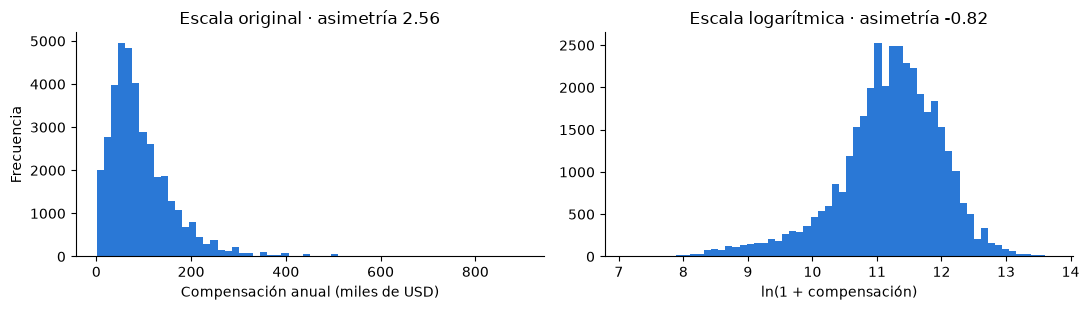

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.hist(df[TARGET] / 1000, bins=60, color="#2a78d6")
a1.set(xlabel="Compensación anual (miles de USD)", ylabel="Frecuencia",
       title=f"Escala original · asimetría {df[TARGET].skew():.2f}")
a2.hist(df["salary_log"], bins=60, color="#2a78d6")
a2.set(xlabel="ln(1 + compensación)",
       title=f"Escala logarítmica · asimetría {df['salary_log'].skew():.2f}")
for a in (a1, a2):
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 1.2 Composición de la muestra

El 85 % de las observaciones corresponde a países de renta alta. Esta representación
desigual condiciona la potencia del análisis de equidad para las regiones de menor
renta, y se declara como limitación en §6.2.1.

In [5]:
comp = (df.groupby("income_group", observed=True)[TARGET]
        .agg(N="count", mediana="median")
        .assign(pct=lambda t: (t.N / len(df) * 100).round(1))
        .sort_values("mediana", ascending=False))
comp

,N,mediana,pct
income_group,,,
High income,32285,86743.0,85.0
Upper middle income,3629,33717.0,9.6
Lower middle income,2050,16964.0,5.4


## 2. Diseño experimental

Diseño factorial entre estrategia de representación de variables categóricas de alta
cardinalidad y arquitectura de modelado, evaluado sobre particiones idénticas para
que la comparación admita contraste pareado.

**Nota sobre el número de repeticiones.** La validación cruzada se repite cuatro
veces. El motivo no es aumentar la potencia sino hacer posible el contraste: la
prueba de Wilcoxon con cinco pares tiene un valor *p* mínimo alcanzable de 0.0625,
superior al nivel de significación de 0.05. Con solo cinco particiones ninguna
hipótesis podría aceptarse, con independencia de los datos.

In [6]:
from scipy.stats import wilcoxon

for n in (5, 10, 20):
    x = np.arange(n, dtype=float)
    print(f"n = {n:>3} pares  →  valor p mínimo alcanzable = {wilcoxon(x, x + 1).pvalue:.6f}")

n =   5 pares  →  valor p mínimo alcanzable = 0.062500
n =  10 pares  →  valor p mínimo alcanzable = 0.001953
n =  20 pares  →  valor p mínimo alcanzable = 0.000008


In [7]:
from src.feature_pipeline_so import preparar_xy, construir_preprocesador
from src.model_registry import build_models
from sklearn.model_selection import train_test_split

X, y, A = preparar_xy(df)
X_ent, X_pru, y_ent, y_pru, A_ent, A_pru = train_test_split(
    X, y, A, test_size=0.20, random_state=SEMILLA, stratify=df["income_group"])

print(f"Predictores: {X.shape[1]}")
print(f"Entrenamiento: {len(X_ent):,}   ·   Prueba: {len(X_pru):,}")
print(f"Modelos disponibles: {', '.join(build_models())}")

Predictores: 119
Entrenamiento: 30,371   ·   Prueba: 7,593
Modelos disponibles: Ridge, HistGradientBoosting, XGBoost, LightGBM, CatBoost


## 3. Entrenamiento y evaluación

La ejecución completa se delega al script del proyecto, que exporta todos los
artefactos. Reproducirla aquí duplicaría la lógica y abriría la posibilidad de que
ambas versiones divergiesen.

In [8]:
# Descomentar para reejecutar el experimento completo (unos 4 minutos).
# import subprocess
# subprocess.run([sys.executable, "scripts/run_experiment.py"], cwd=RAIZ, check=True)

cv = pd.read_csv(RAIZ / "results/cv_by_encoding.csv")
resumen = (cv.groupby(["modelo", "codificacion"])[["R2", "MAE_log", "MAE_USD"]]
           .agg(["mean", "std"]).round(4))
resumen.sort_values(("R2", "mean"), ascending=False)

R2         MAE_log             MAE_USD  \
                                     mean     std    mean     std        mean   
modelo               codificacion                                               
XGBoost              target        0.7866  0.0062  0.2737  0.0028  24785.8327   
CatBoost             target        0.7861  0.0060  0.2739  0.0027  24782.4978   
LightGBM             target        0.7848  0.0063  0.2747  0.0028  24808.1406   
                     onehot        0.7845  0.0062  0.2745  0.0030  24791.9944   
CatBoost             onehot        0.7836  0.0060  0.2755  0.0028  24945.6986   
XGBoost              onehot        0.7826  0.0056  0.2759  0.0024  24976.2420   
HistGradientBoosting target        0.7823  0.0060  0.2768  0.0029  25053.9803   
                     onehot        0.7815  0.0058  0.2769  0.0029  25055.6338   
Ridge                onehot        0.7532  0.0065  0.2975  0.0026  26659.0888   
                     target        0.7494  0.0067  0.3000  0.0025  26802.0087   
Baseline_media       onehot       -0.0001  0.0001  0.6097  0.0051  50110.2688   
                     target       -0.0001  0.0001  0.6097  0.0051  50110.2688   
Baseline_mediana     onehot       -0.0080  0.0013  0.6067  0.0049  49882.9135   
                     target       -0.0080  0.0013  0.6067  0.0049  49882.9135   

                                             
                                        std  
modelo               codificacion            
XGBoost              target        374.8320  
CatBoost             target        403.1827  
LightGBM             target        403.8468  
                     onehot        366.8193  
CatBoost             onehot        415.1469  
XGBoost              onehot        378.2136  
HistGradientBoosting target        431.7533  
                     onehot        389.3872  
Ridge                onehot        418.9769  
                     target        441.1540  
Baseline_media       onehot        623.2351  
                     target        623.2351  
Baseline_mediana     onehot        610.5732  
                     target        610.5732

## 4. Contraste de hipótesis

Los contrastes se agrupan en familias, cada una asociada a la hipótesis que responde.
Comparar todas las configuraciones entre sí obligaría a una corrección por
comparaciones múltiples tan severa que ninguna diferencia real alcanzaría
significación, y además incluiría comparaciones que no responden a ninguna hipótesis.

In [9]:
w = pd.read_csv(RAIZ / "results/wilcoxon_tests.csv")
w = w[w.metrica == "R2"]

print("HE1 — estrategia de codificación, a igualdad de modelo\n")
he1 = w[w.familia == "HE1_codificacion"]
print(he1[["config_a", "config_b", "media_a", "media_b",
           "diferencia", "p_valor", "significativo"]].to_string(index=False))

HE1 — estrategia de codificación, a igualdad de modelo

                   config_a                    config_b  media_a  media_b  diferencia  p_valor  significativo
               Ridge/target                Ridge/onehot   0.7494   0.7532     -0.0038 0.000002           True
            CatBoost/target             CatBoost/onehot   0.7861   0.7836      0.0025 0.000004           True
             XGBoost/target              XGBoost/onehot   0.7866   0.7826      0.0040 0.000006           True
HistGradientBoosting/target HistGradientBoosting/onehot   0.7823   0.7815      0.0008 0.048441          False
            LightGBM/target             LightGBM/onehot   0.7848   0.7845      0.0003 0.812355          False


In [10]:
print("Modelo lineal frente a ensamblados\n")
lin = w[w.familia == "lineal_vs_ensamblado"]
print(lin[["config_a", "config_b", "diferencia", "p_valor", "significativo"]].to_string(index=False))

hg = w[w.familia == "HG_vs_baseline"]
print(f"\nHG — superioridad sobre la línea base: "
      f"{hg.significativo.sum()}/{len(hg)} significativas, p máximo {hg.p_valor.max():.2e}")

Modelo lineal frente a ensamblados

    config_a                    config_b  diferencia  p_valor  significativo
Ridge/onehot             CatBoost/onehot     -0.0304 0.000002           True
Ridge/onehot HistGradientBoosting/onehot     -0.0284 0.000002           True
Ridge/onehot             LightGBM/onehot     -0.0313 0.000002           True
Ridge/onehot              XGBoost/onehot     -0.0294 0.000002           True
Ridge/target             CatBoost/target     -0.0366 0.000002           True
Ridge/target HistGradientBoosting/target     -0.0329 0.000002           True
Ridge/target             LightGBM/target     -0.0353 0.000002           True
Ridge/target              XGBoost/target     -0.0372 0.000002           True

HG — superioridad sobre la línea base: 20/20 significativas, p máximo 1.91e-06


## 5. Explicabilidad

Se emplea el algoritmo específico para modelos de árbol. El estimador basado en
núcleo resultaría impracticable sobre una muestra de esta magnitud.

Los valores calculados se conservan como artefacto y no solo las figuras derivadas,
para permitir su verificación independiente.

In [11]:
shap_res = pd.read_csv(RAIZ / "results/shap_summary_XGBoost_target_2023.csv")
top = shap_res.head(10)[["variable", "shap_medio_abs", "ic_inferior", "ic_superior"]]
top.round(4)

,variable,shap_medio_abs,ic_inferior,ic_superior
0,Country,0.4311,0.4154,0.4449
1,YearsCodePro_num,0.1392,0.1353,0.1432
2,YearsCode_num,0.0386,0.0375,0.0398
3,DevType,0.0379,0.0364,0.0393
4,"OrgSize_10,000 or more employees",0.0346,0.0329,0.0364
5,language__php,0.0308,0.0295,0.0321
6,platform__amazon_web_services_(aws),0.0274,0.0271,0.0277
7,RemoteWork_Remote,0.0249,0.0244,0.0254
8,language__typescript,0.0242,0.0238,0.0246
9,WorkExp_num,0.0230,0.0221,0.0240


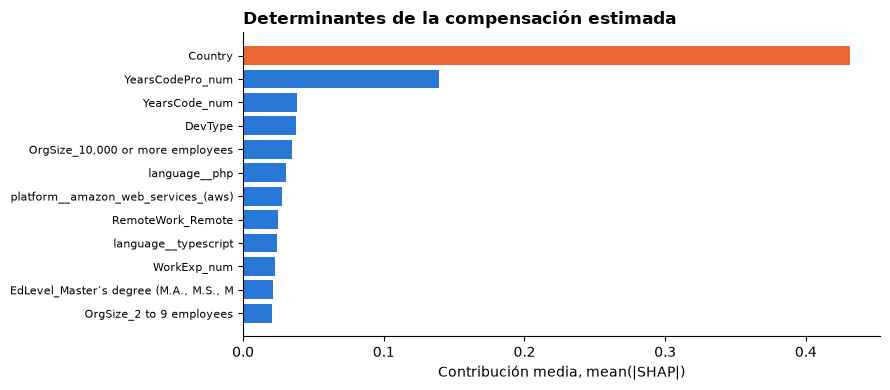

El país aporta 3.1 veces más que los años de experiencia profesional.


In [12]:
t = shap_res.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4))
colores = ["#eb6834" if v == "Country" else "#2a78d6" for v in t.variable]
ax.barh(range(len(t)), t.shap_medio_abs, color=colores)
ax.set_yticks(range(len(t)))
ax.set_yticklabels([v[:38] for v in t.variable], fontsize=8)
ax.set_xlabel("Contribución media, mean(|SHAP|)")
ax.set_title("Determinantes de la compensación estimada", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

pais = float(shap_res.loc[shap_res.variable == "Country", "shap_medio_abs"].iloc[0])
exp = float(shap_res.loc[shap_res.variable == "YearsCodePro_num", "shap_medio_abs"].iloc[0])
print(f"El país aporta {pais/exp:.1f} veces más que los años de experiencia profesional.")

## 6. Auditoría de equidad

**Precisión determinante.** El error absoluto no es comparable entre grupos con
niveles salariales dispares, y su uso conduce a la conclusión contraria a la
correcta. La celda siguiente lo muestra.

In [13]:
import json
aud = json.loads((RAIZ / "results/fairness_income_group_2023.json").read_text())

filas = [{"grupo": g, "N": v["n"],
          "MAE": round(v["mae"]),
          "mediana": round(v["mediana_real"]),
          "MAE/mediana": f"{v['mae_relativo']*100:.1f} %",
          "sesgo": round(v["sesgo_sistematico"])}
         for g, v in aud["por_grupo"].items()]
tabla = pd.DataFrame(filas).sort_values("MAE", ascending=False)
print(tabla.to_string(index=False))

a = aud["agregados"]
print(f"\nRazón de disparidad ABSOLUTA: {a['razon_disparidad_absoluta']:.2f}"
      f"  →  peor servido: {a['grupo_peor_servido_absoluto']}")
print(f"Razón de disparidad RELATIVA: {a['razon_disparidad_relativa']:.2f}"
      f"  →  peor servido: {a['grupo_peor_servido_relativo']}")
print(f"\n¿La conclusión se invierte al normalizar? {a['invierte_al_normalizar']}")

              grupo    N   MAE  mediana MAE/mediana  sesgo
        High income 6457 27113    88173      30.7 %  -6369
Upper middle income  726 16662    32982      50.5 %  -4650
Lower middle income  410  8524    16964      50.2 %  -1947

Razón de disparidad ABSOLUTA: 3.18  →  peor servido: High income
Razón de disparidad RELATIVA: 1.64  →  peor servido: Upper middle income

¿La conclusión se invierte al normalizar? True


### 6.1 Género: la desigualdad del mercado no es sesgo del modelo

La edición 2022 es la última cuya versión pública incluye la variable de género:
Stack Overflow la retiró de sus conjuntos públicos a partir de 2023.

In [14]:
gen = json.loads((RAIZ / "results/fairness_Gender_2022.json").read_text())
for g in ("Man", "Woman", "Non-binary, genderqueer, or gender non-conforming"):
    if g in gen["por_grupo"]:
        v = gen["por_grupo"][g]
        print(f"{g[:32]:34s} N={v['n']:>5,}  error relativo {v['mae_relativo']*100:.1f} %")

c = gen["contrastes"]
print(f"\n{c['prueba']}: p = {c['p_valor']:.3f}"
      f"  →  {'diferencia significativa' if c['significativo'] else 'sin diferencia significativa'}")

Man                                N=5,375  error relativo 35.7 %
Woman                              N=  287  error relativo 34.9 %
Non-binary, genderqueer, or gend   N=   46  error relativo 30.4 %

Kruskal-Wallis: p = 0.455  →  sin diferencia significativa


El modelo estima con la misma exactitud relativa a hombres y a mujeres, **pese a que
la brecha salarial de género está presente en los datos**. Es la distinción central
del trabajo: la desigualdad del mercado y el sesgo del sistema predictivo son
fenómenos distintos.

## 7. Adopción de inteligencia artificial

La asociación bruta entre uso de herramientas de inteligencia artificial y
compensación es inversa y de magnitud apreciable. La pregunta es si persiste al
condicionar por los determinantes establecidos.

In [15]:
ia = pd.read_csv(RAIZ / "results/ia_asociacion.csv")
print(ia[ia.variable == "AISelect"][["categoria", "n", "mediana_usd", "diferencia_pct"]]
      .to_string(index=False))

sh25 = pd.read_csv(RAIZ / "results/shap_summary_XGBoost_target_2025.csv")
suma_ia = sh25[sh25.variable.str.startswith(("AISelect", "AIThreat", "AIAgents",
                                             "LearnCodeAI"))].shap_medio_abs.sum()
pais25 = float(sh25.loc[sh25.variable == "Country", "shap_medio_abs"].iloc[0])
print(f"\nContribución de las 23 variables de IA: {suma_ia:.4f}")
print(f"Contribución del país:                  {pais25:.4f}")
print(f"El país aporta {pais25/suma_ia:.1f} veces más que todas las variables de IA juntas.")

                                  categoria    n  mediana_usd  diferencia_pct
                     No, but I plan to soon  643      89331.0             0.0
                    No, and I don't plan to 2178      87550.0            -2.0
Yes, I use AI tools monthly or infrequently 1980      84845.5            -5.0
                 Yes, I use AI tools weekly 2761      82370.0            -7.8
                  Yes, I use AI tools daily 7453      81685.0            -8.6

Contribución de las 23 variables de IA: 0.0653
Contribución del país:                  0.4354
El país aporta 6.7 veces más que todas las variables de IA juntas.


La asociación bruta se desvanece al condicionar: constituye un **artefacto de
composición** de la muestra, no un efecto atribuible a la adopción de estas
herramientas.

> El diseño es transversal y las variables son autorreportadas. Este resultado no
> admite lectura causal en ningún sentido: lo que permite afirmar es que la
> diferencia observable se explica por las características de ambos grupos, no que
> la adopción carezca de efecto sobre la compensación.

## 8. Síntesis

| Hipótesis | Veredicto |
|---|---|
| **HG** — más exacto que la línea base, explicable y auditable | Se acepta |
| **HE1** — la codificación por objetivo supera a la disyuntiva | **Se rechaza**: el efecto cambia de signo según la familia del modelo |
| **HE2** — el capital humano predice más que lo demográfico | Se acepta, pero el bloque geográfico supera a ambos |
| **HE3** — SHAP revela lo que la impureza no captura | Se acepta (ρ = 0.776) |
| **HE4** — hay disparidades sistemáticas del error | Se acepta parcialmente: regional sí, de género no |
| **HE5** — la asociación IA-salario no persiste tras el control | Se acepta |

**Hallazgo principal:** el país concentra una contribución tres veces superior a la de
la experiencia profesional. En el mercado analizado, la ubicación pesa más que la
trayectoria.

---

*Para reproducir el trabajo completo desde cero, véase `docs/REPOSITORIOS.md`.*